# 📊 Credit Risk Monitor — Scoring Pipeline

**Author:** Thanh Pham | Credit Risk Analyst  
**Reference Date:** 31 December 2025  
**Portfolio:** 25 Entities — 15 Banks / 10 Sovereigns  
**Kernel:** `final_project` (conda)

---

## Purpose

This is the **live monitoring notebook** — completely independent from `credit_report.py` (PDF generator).
It reads raw financial/macro factor data from CSV files and **calculates every score from scratch**.

### Workflow
```
data/banks_sample.csv          ┐
data/sovereigns_sample.csv     ├─► Score calculation ─► Ratings ─► Watchlist ─► Charts
data/market_data_sample.csv    ┘
```

### How to update for a new period
1. Update the CSV files in `data/` with fresh factor data
2. Change `REF_DATE` in Section 1
3. Run all cells — scores, ratings, watchlist, and charts regenerate automatically

> ⚠️ Run cells top-to-bottom. Each section depends on data computed above it.


## 1 · Environment & Imports


In [26]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': '#F8F9FA',
    'axes.facecolor': '#F8F9FA', 'axes.spines.top': False, 'axes.spines.right': False,
})

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data').exists())
DATA_DIR = ROOT / 'data'

# ── Reference date ────────────────────────────────────────────────────────────
REF_DATE = '31 December 2025'

# ── Colour palette (mirrors PDF report) ──────────────────────────────────────
RATING_COLOURS = {'AA':'#1E5799','A':'#1A6FA5','BBB':'#2980B9',
                  'BB':'#B8860B','B':'#E67E22','CCC':'#C0392B'}
ACTION_COLOURS = {'Monitor':'#1E8449','Review':'#E67E22','Escalate':'#C0392B'}

print(f'✅ Imports OK  |  Data directory: {DATA_DIR}')


✅ Imports OK  |  Data directory: /Users/phamthanh/Documents/ESSCA | MSc Finance & Data Analyst/Semester 2/16. Credit Risk Project/data


## 2 · Load Raw Data from CSV Files

Three CSV files are read here. These are the **only files you edit** when refreshing the monitor.

| File | Contents | Rows |
|------|----------|---------|
| `data/banks_sample.csv` | 7 financial ratios per bank | 15 |
| `data/sovereigns_sample.csv` | 7 macro-fiscal indicators per sovereign | 10 |
| `data/market_data_sample.csv` | Daily CDS, spread, equity, vol per entity | ~1,700 |


In [27]:
banks      = pd.read_csv(DATA_DIR / 'banks_sample.csv')
sovereigns = pd.read_csv(DATA_DIR / 'sovereigns_sample.csv')
market     = pd.read_csv(DATA_DIR / 'market_data_sample.csv', parse_dates=['date'])

print(f'Banks loaded      : {len(banks)} rows')
print(f'Sovereigns loaded : {len(sovereigns)} rows')
print(f'Market rows       : {len(market):,}  '
      f'({market["date"].nunique()} dates × {market["entity_name"].nunique()} entities)')
print(f'Market date range : {market["date"].min().date()} → {market["date"].max().date()}')

print('\n--- BANK COLUMNS ---'); print(banks.columns.tolist())
print('\n--- SOVEREIGN COLUMNS ---'); print(sovereigns.columns.tolist())


Banks loaded      : 15 rows
Sovereigns loaded : 10 rows
Market rows       : 1,650  (66 dates × 25 entities)
Market date range : 2025-10-01 → 2025-12-31

--- BANK COLUMNS ---
['name', 'cet1_ratio', 'npl_ratio', 'roe', 'leverage_ratio', 'loan_to_deposit', 'cost_to_income', 'liquidity_ratio', 'ext_rating']

--- SOVEREIGN COLUMNS ---
['name', 'debt_gdp', 'fiscal_balance', 'inflation', 'fx_reserves_months', 'gdp_growth', 'political_risk', 'current_account', 'ext_rating']


## 3 · Bank Scoring — 7-Factor Weighted Model

Each of the 7 factors is **normalised** against the peer distribution, then multiplied
by its weight. A higher component score always means **lower risk**.

### Factor weights
| Factor | Weight | Direction | Notes |
|--------|--------|-----------|-------|
| CET1 ratio | **25%** | Higher = better | Core capital buffer |
| NPL ratio | **20%** | Lower = better | Asset quality |
| ROE | **15%** | Higher = better | Profitability |
| Leverage ratio | **10%** | Higher = better | Structural solvency |
| Loan-to-deposit | **10%** | Lower = better | Funding stability |
| Cost-to-income | **10%** | Lower = better | Efficiency |
| Liquidity ratio | **10%** | Higher = better | Short-term resilience |

### Normalisation
```
component_score = clip((factor − peer_min) / (peer_max − peer_min), 0, 1) × 100
```
For inverse factors (NPL, LDR, CTI) the formula is flipped:
```
component_score = clip((peer_max − factor) / (peer_max − peer_min), 0, 1) × 100
```


In [28]:
# ── Bank model weights ────────────────────────────────────────────────────────
BANK_FACTORS = [
    # (column,           weight, inverse)
    ('cet1_ratio',       0.25,   False),   # higher = better
    ('npl_ratio',        0.20,   True),    # lower  = better
    ('roe',              0.15,   False),
    ('leverage_ratio',   0.10,   False),
    ('loan_to_deposit',  0.10,   True),
    ('cost_to_income',   0.10,   True),
    ('liquidity_ratio',  0.10,   False),
]

def normalise(series: pd.Series, inverse: bool) -> pd.Series:
    """Min-max normalise to [0, 100]; flip direction for inverse factors."""
    lo, hi = series.min(), series.max()
    if hi == lo:                         # all identical → neutral 50
        return pd.Series(50.0, index=series.index)
    if inverse:
        return ((hi - series) / (hi - lo)).clip(0, 1) * 100
    return ((series - lo) / (hi - lo)).clip(0, 1) * 100


def compute_bank_scores(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate the internal composite score for each bank.
    Returns a copy of df with one column per component score plus 'score'.
    """
    out = df.copy()
    weighted_sum = pd.Series(0.0, index=df.index)

    for col, weight, inverse in BANK_FACTORS:
        comp_col = f'comp_{col}'
        out[comp_col] = normalise(df[col], inverse)
        weighted_sum  += out[comp_col] * weight

    out['score'] = weighted_sum.round(2)
    return out


banks_scored = compute_bank_scores(banks)

# Show the component breakdown
comp_cols = [f'comp_{c}' for c, *_ in BANK_FACTORS]
display_cols = ['name'] + [c for c, *_ in BANK_FACTORS] + comp_cols + ['score']

print('=== Bank Factor Data & Component Scores ===')
pd.set_option('display.max_columns', 30)
banks_scored[display_cols].sort_values('score').style\
    .background_gradient(subset=comp_cols, cmap='RdYlGn', vmin=0, vmax=100)\
    .format({c: '{:.1f}' for c in comp_cols + ['score']})\
    .set_caption(f'Bank component scores (0–100 per factor) — {REF_DATE}')


=== Bank Factor Data & Component Scores ===


,name,cet1_ratio,npl_ratio,roe,leverage_ratio,loan_to_deposit,cost_to_income,liquidity_ratio,comp_cet1_ratio,comp_npl_ratio,comp_roe,comp_leverage_ratio,comp_loan_to_deposit,comp_cost_to_income,comp_liquidity_ratio,score
14,Monte dei Paschi,18.300000,12.400000,-2.500000,3.900000,95.000000,88.400000,112.000000,100.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0
7,Societe Generale,13.100000,3.800000,5.400000,4.100000,91.300000,78.600000,112.900000,5.5,74.1,42.2,4.8,13.8,27.0,2.5,27.3
3,Deutsche Bank,13.400000,3.100000,6.100000,4.200000,88.200000,74.300000,118.200000,10.9,80.2,46.0,7.1,25.4,38.8,17.1,34.5
5,Santander,12.800000,3.400000,8.900000,5.300000,86.100000,68.900000,121.300000,0.0,77.6,61.0,33.3,33.2,53.7,25.6,39.2
2,BNP Paribas,12.900000,2.400000,8.300000,4.900000,84.600000,67.800000,124.700000,1.8,86.2,57.8,23.8,38.8,56.7,35.0,41.8
13,Commerzbank,14.600000,3.300000,7.200000,4.800000,85.900000,71.200000,119.800000,32.7,78.4,51.9,21.4,34.0,47.4,21.5,44.1
8,Barclays,14.200000,2.600000,9.100000,5.100000,81.700000,66.100000,127.300000,25.5,84.5,62.0,28.6,49.6,61.4,42.1,50.7
1,HSBC,14.100000,2.100000,9.800000,5.800000,79.300000,63.200000,131.400000,23.6,88.8,65.8,45.2,58.6,69.4,53.4,56.2
12,ABN AMRO,15.100000,2.900000,9.400000,5.600000,80.300000,64.700000,129.600000,41.8,81.9,63.6,40.5,54.9,65.3,48.5,57.3
4,UniCredit,15.700000,2.800000,11.400000,6.100000,76.400000,61.500000,135.800000,52.7,82.8,74.3,52.4,69.4,74.1,65.6,67.0


## 4 · Sovereign Scoring — 7-Factor Macro-Fiscal Model

Same normalisation approach as banks, but factors reflect **macro-fiscal creditworthiness**.

### Factor weights
| Factor | Weight | Direction | Notes |
|--------|--------|-----------|-------|
| Debt / GDP | **25%** | Lower = better | Primary fiscal burden |
| Fiscal balance | **20%** | Higher = better | Deficit/surplus (% GDP) |
| Inflation | **15%** | Lower = better | Price stability |
| FX reserves (months) | **15%** | Higher = better | External buffer |
| GDP growth | **10%** | Higher = better | Economic momentum |
| Political risk (1–10) | **10%** | Lower = better | Institutional stability |
| Current account | **5%** | Higher = better | External balance |


In [29]:
SOVEREIGN_FACTORS = [
    ('debt_gdp',            0.25, True),    # lower  = better
    ('fiscal_balance',      0.20, False),   # higher = better (less negative)
    ('inflation',           0.15, True),    # lower  = better
    ('fx_reserves_months',  0.15, False),
    ('gdp_growth',          0.10, False),
    ('political_risk',      0.10, True),    # lower  = better
    ('current_account',     0.05, False),
]


def compute_sovereign_scores(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    weighted_sum = pd.Series(0.0, index=df.index)
    for col, weight, inverse in SOVEREIGN_FACTORS:
        comp_col = f'comp_{col}'
        out[comp_col] = normalise(df[col], inverse)
        weighted_sum  += out[comp_col] * weight
    out['score'] = weighted_sum.round(2)
    return out


sovereigns_scored = compute_sovereign_scores(sovereigns)

sov_comp = [f'comp_{c}' for c, *_ in SOVEREIGN_FACTORS]
sov_display = ['name'] + [c for c, *_ in SOVEREIGN_FACTORS] + sov_comp + ['score']

print('=== Sovereign Factor Data & Component Scores ===')
sovereigns_scored[sov_display].sort_values('score').style\
    .background_gradient(subset=sov_comp, cmap='RdYlGn', vmin=0, vmax=100)\
    .format({c: '{:.1f}' for c in sov_comp + ['score']})\
    .set_caption(f'Sovereign component scores (0–100 per factor) — {REF_DATE}')


=== Sovereign Factor Data & Component Scores ===


,name,debt_gdp,fiscal_balance,inflation,fx_reserves_months,gdp_growth,political_risk,current_account,comp_debt_gdp,comp_fiscal_balance,comp_inflation,comp_fx_reserves_months,comp_gdp_growth,comp_political_risk,comp_current_account,score
9,Brazil,89.200000,-6.800000,5.100000,3.100000,2.100000,5.000000,-1.800000,73.7,0.0,92.9,4.1,73.3,36.4,32.4,45.6
8,Turkey,31.100000,-5.200000,48.000000,4.200000,2.900000,7.000000,-3.500000,100.0,34.0,0.0,26.5,100.0,0.0,16.2,46.6
5,Italy,143.900000,-4.400000,1.800000,3.200000,-0.100000,3.500000,0.400000,49.0,51.1,100.0,6.1,0.0,63.6,53.3,47.4
2,United States,123.300000,-6.300000,3.100000,3.200000,2.800000,2.500000,-3.100000,58.3,10.6,97.2,6.1,96.7,81.8,20.0,51.1
1,France,111.900000,-5.500000,2.300000,4.100000,0.800000,3.000000,-0.800000,63.5,27.7,98.9,24.5,30.0,72.7,41.9,52.3
7,Greece,184.800000,-2.800000,3.200000,2.900000,2.000000,3.500000,-5.200000,30.5,85.1,97.0,0.0,70.0,63.6,0.0,52.6
3,United Kingdom,101.200000,-4.800000,2.600000,3.800000,0.400000,2.500000,-2.900000,68.3,42.6,98.3,18.4,16.7,81.8,21.9,54.0
4,Japan,252.400000,-3.900000,2.900000,5.100000,1.900000,1.500000,3.800000,0.0,61.7,97.6,44.9,66.7,100.0,85.7,54.7
6,Spain,107.400000,-3.600000,2.100000,3.900000,2.300000,2.500000,2.100000,65.5,68.1,99.4,20.4,80.0,81.8,69.5,67.6
0,Germany,66.300000,-2.100000,2.000000,7.800000,1.900000,2.000000,5.300000,84.1,100.0,99.6,100.0,66.7,90.9,100.0,91.7


## 5 · Rating Mapping & Watchlist Logic

Scores are mapped to letter ratings, then watchlist flags and action tiers are derived.

### Rating thresholds
| Score | Rating |
|-------|--------|
| ≥ 85 | AA |
| ≥ 75 | A |
| ≥ 65 | BBB |
| ≥ 55 | BB |
| ≥ 40 | B |
| < 40 | CCC |

### Watchlist triggers (any one is sufficient)
1. Internal score < 60  
2. ≥ 2 active market alerts on the reference date  
3. Score deterioration > 10 pts vs prior snapshot  


In [30]:
THRESHOLDS = [(85,'AA'),(75,'A'),(65,'BBB'),(55,'BB'),(40,'B'),(0,'CCC')]

def score_to_rating(score: float) -> str:
    for cutoff, label in THRESHOLDS:
        if score >= cutoff:
            return label
    return 'CCC'


def rating_to_action(rating: str, alerts: int) -> str:
    if rating == 'CCC':                          return 'Escalate'
    if rating in ('B','BB') and alerts >= 2:     return 'Review'
    if rating in ('B','BB','BBB') and alerts >= 1: return 'Review'
    return 'Monitor'


# ── Pull last-date market signals ─────────────────────────────────────────────
last_date   = market['date'].max()
last_market = market[market['date'] == last_date].copy()
last_market['alert_count'] = (last_market[['cds_alert','spread_alert',
                                            'equity_alert','vol_alert']].sum(axis=1))

# ── Combine scored banks + sovereigns ────────────────────────────────────────
banks_scored['type']      = 'Bank'
sovereigns_scored['type'] = 'Sovereign'

# Align columns before concat
common = ['name','type','score','ext_rating']
portfolio = pd.concat([
    banks_scored[common],
    sovereigns_scored[common],
], ignore_index=True)

# Merge market signals
portfolio = portfolio.merge(
    last_market[['entity_name','cds_5y_bps','bond_spread_bps',
                 'equity_return_5d','equity_vol_30d','alert_count']],
    left_on='name', right_on='entity_name', how='left'
).drop(columns='entity_name')

# Derive rating & action
portfolio['int_rating'] = portfolio['score'].apply(score_to_rating)
portfolio['watchlist']  = (portfolio['score'] < 60) | (portfolio['alert_count'] >= 2)
portfolio['action']     = portfolio.apply(
    lambda r: rating_to_action(r['int_rating'], r['alert_count']), axis=1)
portfolio['eq_5d_pct']  = portfolio['equity_return_5d'] * 100

portfolio = portfolio.sort_values('score').reset_index(drop=True)

print(f'Portfolio assembled: {len(portfolio)} entities')
print(f'Watchlisted: {portfolio["watchlist"].sum()}')
print('\nRating distribution:')
print(portfolio.groupby('int_rating')['name'].count().rename('count'))


Portfolio assembled: 25 entities
Watchlisted: 17

Rating distribution:
int_rating
A       1
AA      2
B      11
BB      2
BBB     5
CCC     4
Name: count, dtype: int64


## 6 · Portfolio Summary — KPIs & Styled Table


In [31]:
n  = len(portfolio)
wl = portfolio['watchlist']
print('=' * 60)
print(f'  Portfolio KPIs — {REF_DATE}')
print('=' * 60)
print(f'  Total entities              : {n}')
print(f'  On watchlist                : {wl.sum()} ({wl.sum()/n:.0%})')
print(f'  Escalate                    : {(portfolio["action"]=="Escalate").sum()}')
print(f'  Review                      : {(portfolio["action"]=="Review").sum()}')
print(f'  Investment-grade (internal) : {portfolio["int_rating"].isin(["AA","A","BBB"]).sum()}')
print(f'  Avg CDS — watchlist         : {portfolio.loc[wl,"cds_5y_bps"].mean():.1f} bp')
print(f'  Avg CDS — non-watchlist     : {portfolio.loc[~wl,"cds_5y_bps"].mean():.1f} bp')
print(f'  CDS ratio (WL / non-WL)     : {portfolio.loc[wl,"cds_5y_bps"].mean()/portfolio.loc[~wl,"cds_5y_bps"].mean():.1f}x')
print('=' * 60)


  Portfolio KPIs — 31 December 2025
  Total entities              : 25
  On watchlist                : 17 (68%)
  Escalate                    : 4
  Review                      : 3
  Investment-grade (internal) : 8
  Avg CDS — watchlist         : 137.5 bp
  Avg CDS — non-watchlist     : 45.4 bp
  CDS ratio (WL / non-WL)     : 3.0x


In [32]:
# ── Styled portfolio table ────────────────────────────────────────────────────
SHOW = ['name','type','score','int_rating','ext_rating',
        'cds_5y_bps','bond_spread_bps','eq_5d_pct','equity_vol_30d','alert_count','action']
LABELS = {'name':'Entity','type':'Type','score':'Score','int_rating':'Int. Rating',
          'ext_rating':'Ext. Rating','cds_5y_bps':'CDS (bp)',
          'bond_spread_bps':'Spread (bp)','eq_5d_pct':'Eq 5d (%)',
          'equity_vol_30d':'Vol (%)','alert_count':'Alerts','action':'Action'}

def _score_color(v):
    if v<40: return 'color:#C0392B;font-weight:bold'
    if v<55: return 'color:#E67E22;font-weight:bold'
    if v<65: return 'color:#B8860B'
    return 'color:#1E8449'

def _cds_color(v):
    if v>200: return 'color:#C0392B;font-weight:bold'
    if v>100: return 'color:#E67E22'
    return 'color:#1A6FA5'

def _action_color(v):
    return f'color:{ACTION_COLOURS.get(v,"#333")};font-weight:bold'

def _row_bg(row):
    if row.get('action') == 'Escalate': return ['background-color:#FDECEA']*len(row)
    if row.get('watchlist'):            return ['background-color:#FEF9F0']*len(row)
    return ['']*len(row)

tbl = portfolio[SHOW + ['watchlist']].rename(columns=LABELS)
(
    tbl.style
    .apply(lambda r: _row_bg(r), axis=1)
    .map(_score_color,  subset=['Score'])
    .map(_cds_color,    subset=['CDS (bp)'])
    .map(_action_color, subset=['Action'])
    .format({'Score':'{:.2f}','CDS (bp)':'{:.1f}','Spread (bp)':'{:.1f}',
             'Eq 5d (%)':'{:+.1f}','Vol (%)':'{:.1f}'})
    .hide(subset=['watchlist'], axis='columns')
    .set_caption(f'Full Portfolio — sorted by internal score (ascending) | {REF_DATE}')
)


,Entity,Type,Score,Int. Rating,Ext. Rating,CDS (bp),Spread (bp),Eq 5d (%),Vol (%),Alerts,Action
0,Monte dei Paschi,Bank,25.00,CCC,B,306.1,310.1,+2.2,46.1,1,Escalate
1,Societe Generale,Bank,27.33,CCC,A-,129.2,127.6,+1.4,26.3,0,Escalate
2,Deutsche Bank,Bank,34.50,CCC,BBB+,123.2,131.8,+0.0,28.9,0,Escalate
3,Santander,Bank,39.25,CCC,A-,86.7,90.5,-1.5,23.5,0,Escalate
4,BNP Paribas,Bank,41.79,B,A+,74.2,77.8,-0.8,24.1,0,Monitor
5,Commerzbank,Bank,44.08,B,BBB+,111.6,119.4,-0.0,37.2,1,Review
6,Brazil,Sovereign,45.57,B,BB-,281.3,315.0,-2.1,38.7,1,Review
7,Turkey,Sovereign,46.60,B,B+,472.9,479.4,-3.8,53.5,3,Review
8,Italy,Sovereign,47.42,B,BBB,147.7,160.9,-1.7,31.2,0,Monitor
9,Barclays,Bank,50.74,B,A-,78.2,75.3,+2.9,25.0,0,Monitor


## 7 · Score Factor Contribution — Stacked Bar Chart

Shows **how much each factor contributes** to every entity's final score.
This is the key chart for explaining *why* a score is what it is.


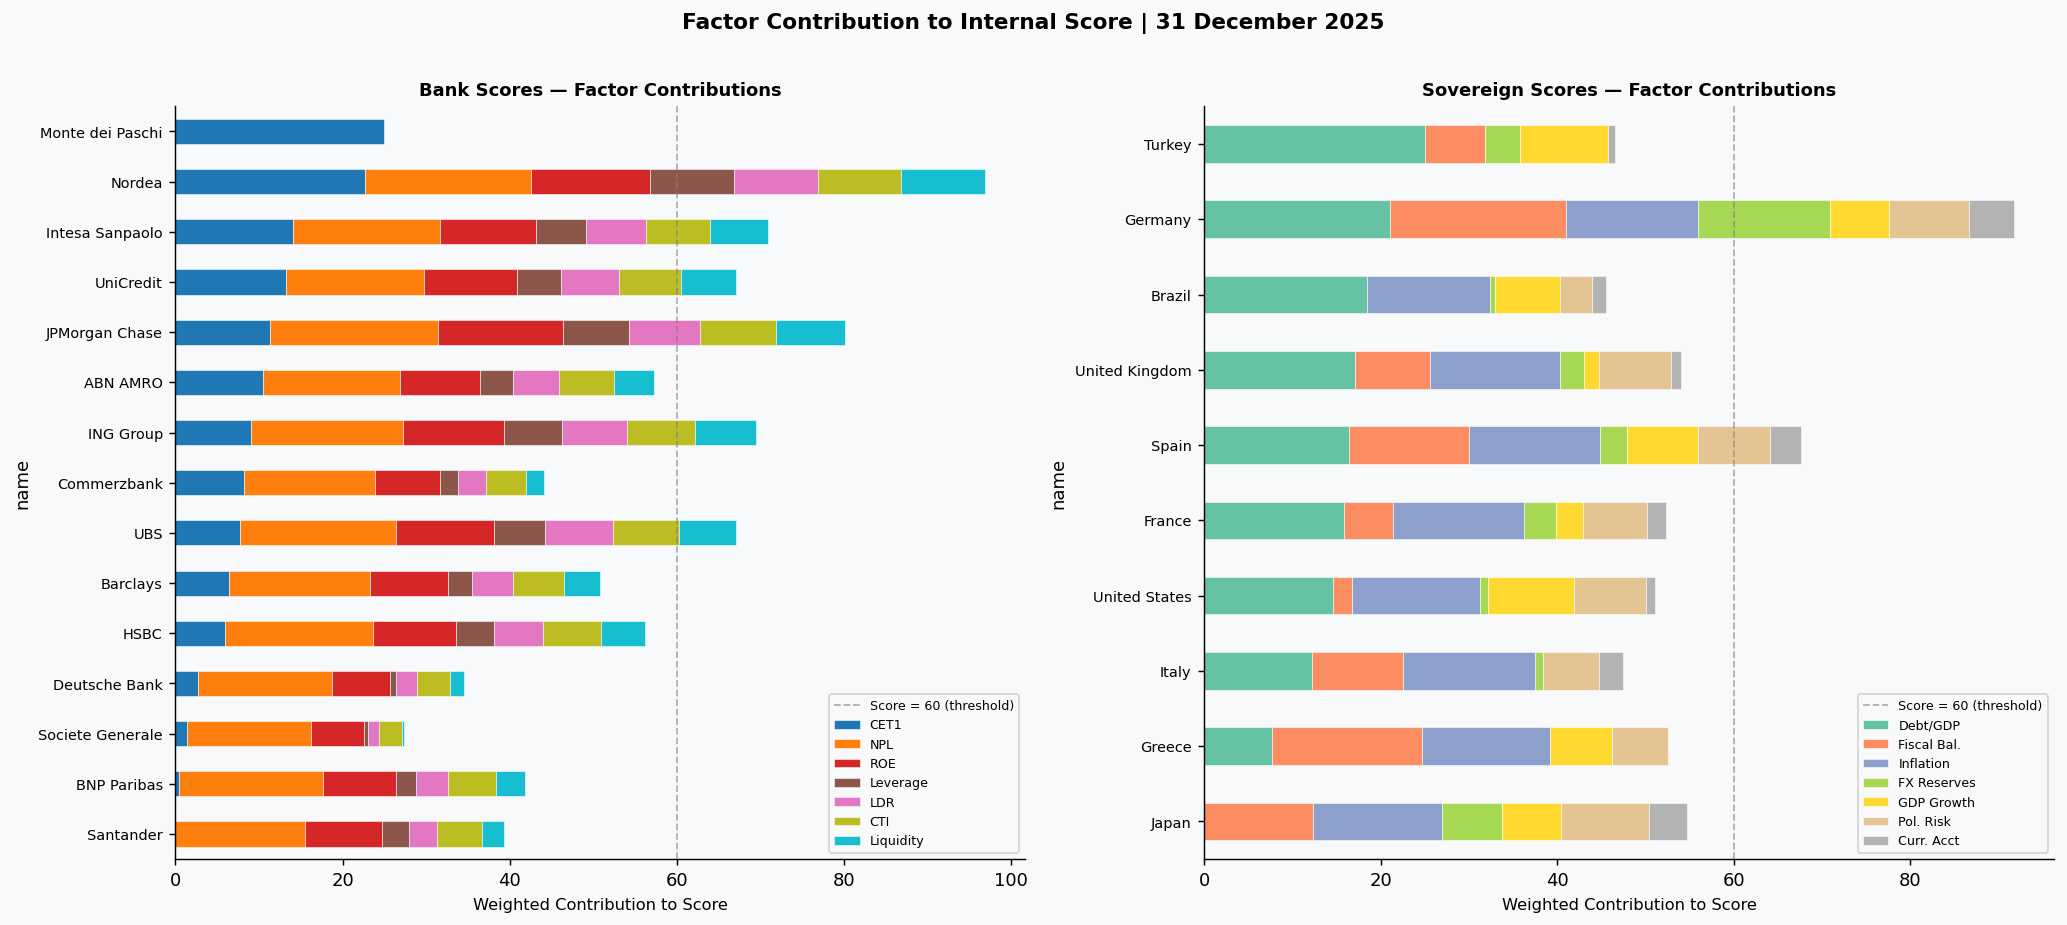

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)

# ── Banks ─────────────────────────────────────────────────────────────────────
bank_comp_cols  = [f'comp_{c}' for c, *_ in BANK_FACTORS]
bank_weights    = [w for _, w, _ in BANK_FACTORS]
bank_labels     = ['CET1','NPL','ROE','Leverage','LDR','CTI','Liquidity']
bank_contrib    = banks_scored.copy()
for col, (_, w, _) in zip(bank_comp_cols, BANK_FACTORS):
    bank_contrib[f'wt_{col}'] = banks_scored[col] * w
wt_cols_b = [f'wt_{c}' for c in bank_comp_cols]
bank_plot = bank_contrib.set_index('name')[wt_cols_b].rename(
    columns=dict(zip(wt_cols_b, bank_labels))).sort_values(bank_labels[0], ascending=True)

cmap_b = plt.cm.get_cmap('tab10', len(bank_labels))
bank_plot.plot(kind='barh', stacked=True, ax=axes[0],
               color=[cmap_b(i) for i in range(len(bank_labels))],
               edgecolor='white', linewidth=0.3)
axes[0].axvline(60, ls='--', lw=1, color='grey', alpha=0.6, label='Score = 60 (threshold)')
axes[0].set_xlabel('Weighted Contribution to Score', fontsize=9)
axes[0].set_title('Bank Scores — Factor Contributions', fontsize=10, fontweight='bold')
axes[0].legend(fontsize=7, loc='lower right')
axes[0].tick_params(axis='y', labelsize=8)

# ── Sovereigns ────────────────────────────────────────────────────────────────
sov_comp_cols = [f'comp_{c}' for c, *_ in SOVEREIGN_FACTORS]
sov_labels    = ['Debt/GDP','Fiscal Bal.','Inflation','FX Reserves','GDP Growth','Pol. Risk','Curr. Acct']
sov_contrib   = sovereigns_scored.copy()
for col, (_, w, _) in zip(sov_comp_cols, SOVEREIGN_FACTORS):
    sov_contrib[f'wt_{col}'] = sovereigns_scored[col] * w
wt_cols_s = [f'wt_{c}' for c in sov_comp_cols]
sov_plot = sov_contrib.set_index('name')[wt_cols_s].rename(
    columns=dict(zip(wt_cols_s, sov_labels))).sort_values(sov_labels[0], ascending=True)

cmap_s = plt.cm.get_cmap('Set2', len(sov_labels))
sov_plot.plot(kind='barh', stacked=True, ax=axes[1],
              color=[cmap_s(i) for i in range(len(sov_labels))],
              edgecolor='white', linewidth=0.3)
axes[1].axvline(60, ls='--', lw=1, color='grey', alpha=0.6, label='Score = 60 (threshold)')
axes[1].set_xlabel('Weighted Contribution to Score', fontsize=9)
axes[1].set_title('Sovereign Scores — Factor Contributions', fontsize=10, fontweight='bold')
axes[1].legend(fontsize=7, loc='lower right')
axes[1].tick_params(axis='y', labelsize=8)

fig.suptitle(f'Factor Contribution to Internal Score | {REF_DATE}',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 8 · CDS Ranking — All Entities

Coloured by internal rating. Dashed lines = 100 bp (amber) and 200 bp (red) stress thresholds.


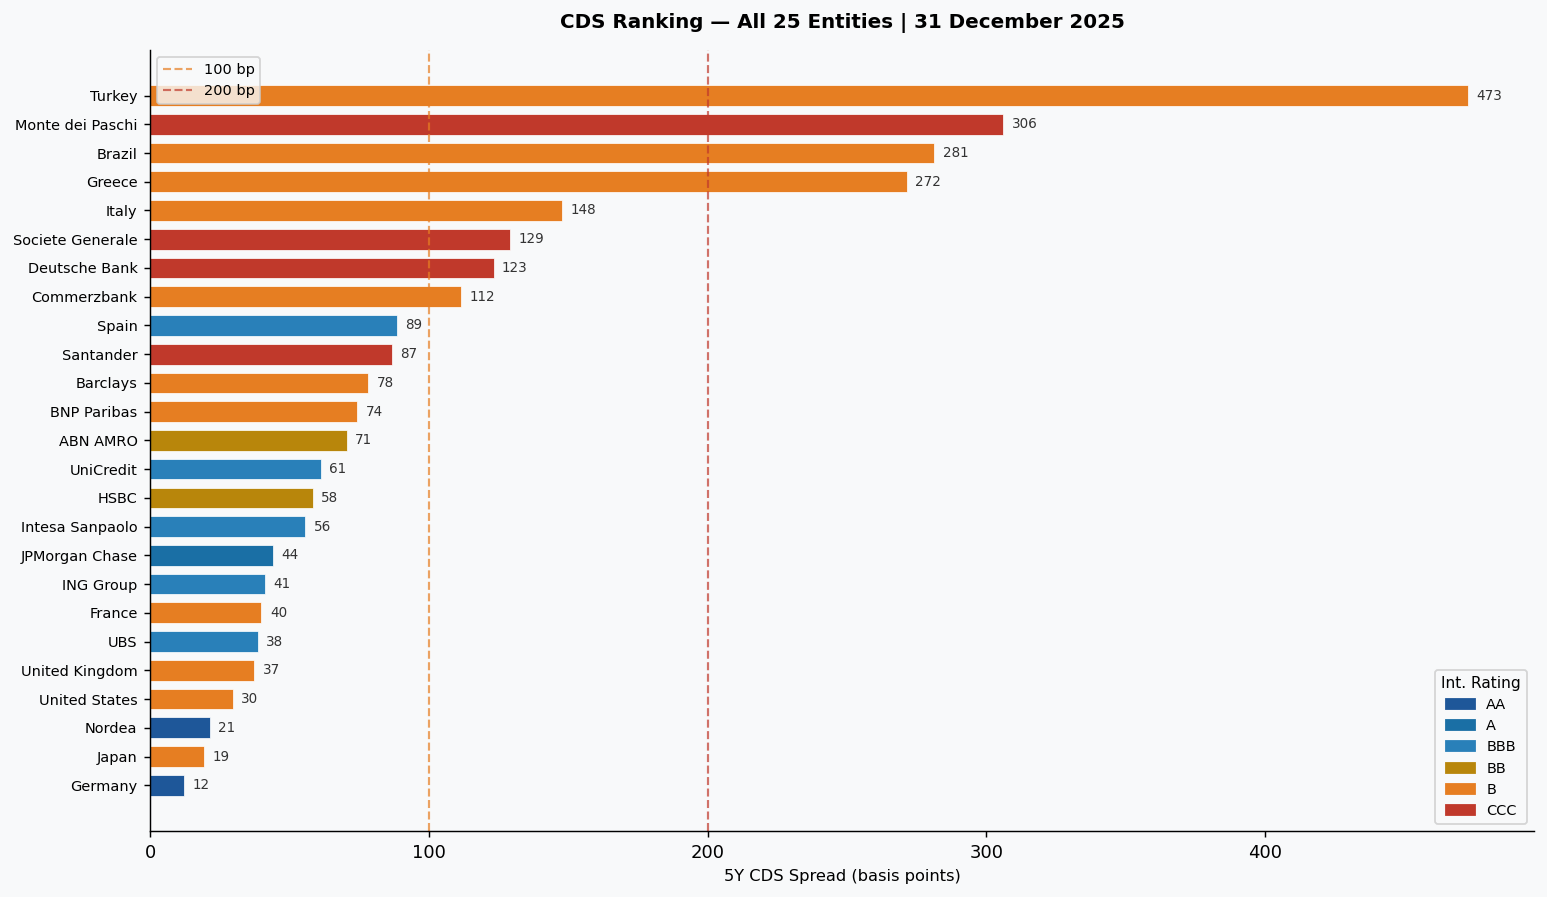

In [34]:
fig, ax = plt.subplots(figsize=(12, 7))
p = portfolio.sort_values('cds_5y_bps').reset_index(drop=True)
colors = p['int_rating'].map(RATING_COLOURS).tolist()
bars = ax.barh(p['name'], p['cds_5y_bps'], color=colors,
               edgecolor='white', linewidth=0.4, height=0.72)
ax.axvline(100, ls='--', lw=1.2, color='#E67E22', alpha=0.7, label='100 bp')
ax.axvline(200, ls='--', lw=1.2, color='#C0392B', alpha=0.7, label='200 bp')
for bar, val in zip(bars, p['cds_5y_bps']):
    ax.text(val+3, bar.get_y()+bar.get_height()/2, f'{val:.0f}',
            va='center', fontsize=7.5, color='#333')
patches = [mpatches.Patch(color=c, label=r) for r, c in RATING_COLOURS.items()]
leg1 = ax.legend(handles=patches, title='Int. Rating', loc='lower right',
                 fontsize=8, title_fontsize=8.5)
ax.add_artist(leg1)
ax.legend(loc='upper left', fontsize=8)
ax.set_xlabel('5Y CDS Spread (basis points)', fontsize=9)
ax.set_title(f'CDS Ranking — All 25 Entities | {REF_DATE}',
             fontsize=11, fontweight='bold', pad=12)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout(); plt.show()


## 9 · Risk Map — Score vs CDS

Top-left = highest risk (low score, wide CDS). Dot size = alert count. Squares = Sovereigns.


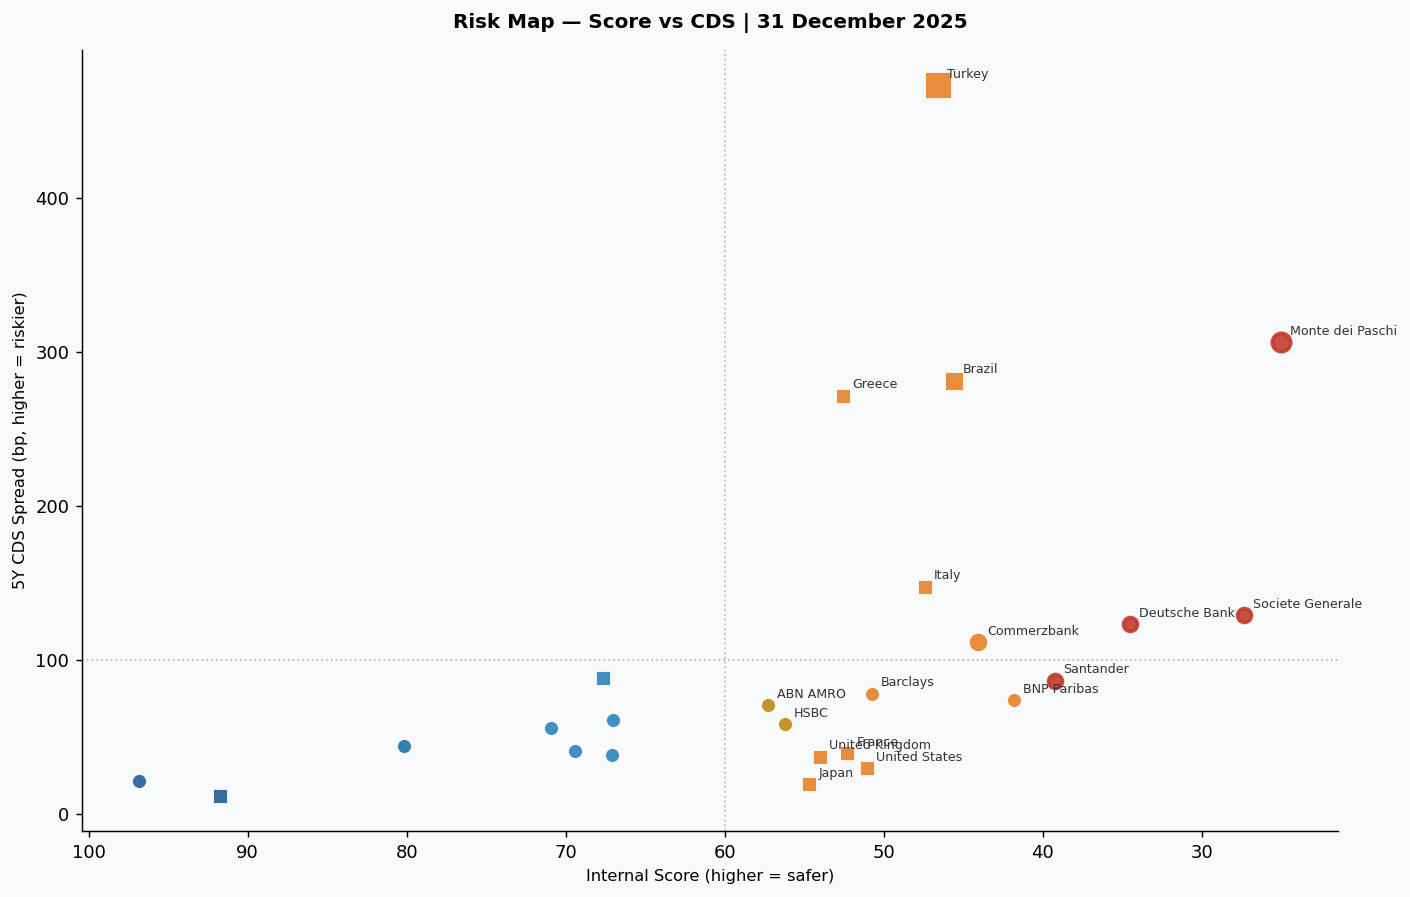

In [35]:
fig, ax = plt.subplots(figsize=(11, 7))
for _, row in portfolio.iterrows():
    sz  = 60 + row['alert_count']*45
    mrk = 's' if row['type']=='Sovereign' else 'o'
    col = RATING_COLOURS.get(row['int_rating'],'#888')
    edg = '#C0392B' if row['action']=='Escalate' else 'white'
    lw  = 2 if row['action']=='Escalate' else 0.5
    ax.scatter(row['score'], row['cds_5y_bps'], s=sz, c=col,
               marker=mrk, edgecolors=edg, linewidths=lw, alpha=0.88, zorder=3)
    if row['watchlist']:
        ax.annotate(row['name'], (row['score'], row['cds_5y_bps']),
                    textcoords='offset points', xytext=(5, 4),
                    fontsize=7, color='#333')
ax.axvline(60, ls=':', lw=1, color='grey', alpha=0.5)
ax.axhline(100, ls=':', lw=1, color='grey', alpha=0.5)
ax.invert_xaxis()
ax.set_xlabel('Internal Score (higher = safer)', fontsize=9)
ax.set_ylabel('5Y CDS Spread (bp, higher = riskier)', fontsize=9)
ax.set_title(f'Risk Map — Score vs CDS | {REF_DATE}',
             fontsize=11, fontweight='bold', pad=12)
plt.tight_layout(); plt.show()


## 10 · CDS Time Series — Watchlist Names

Shows how CDS spreads evolved over the monitoring window for the highest-risk entities.
Uses the daily `market_data_sample.csv` data.


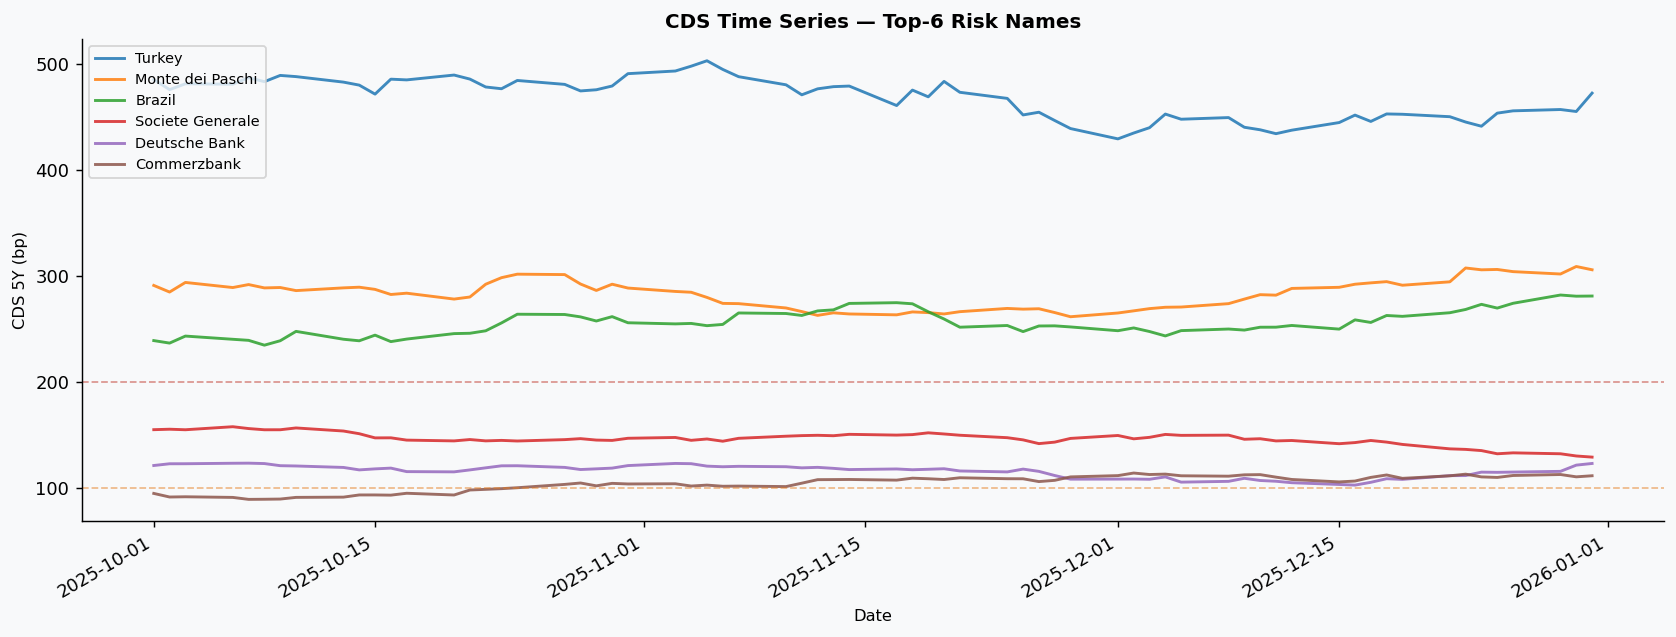

In [36]:
highlight_names = portfolio[portfolio['action'].isin(['Escalate','Review'])]\
                      .nlargest(6,'cds_5y_bps')['name'].tolist()

fig, ax = plt.subplots(figsize=(13, 5))
color_cycle = plt.cm.tab10.colors
for i, entity in enumerate(highlight_names):
    sub = market[market['entity_name']==entity].sort_values('date')
    ax.plot(sub['date'], sub['cds_5y_bps'], label=entity,
            color=color_cycle[i], linewidth=1.6, alpha=0.85)

ax.axhline(100, ls='--', lw=1, color='#E67E22', alpha=0.5)
ax.axhline(200, ls='--', lw=1, color='#C0392B', alpha=0.5)
ax.set_xlabel('Date', fontsize=9)
ax.set_ylabel('CDS 5Y (bp)', fontsize=9)
ax.set_title('CDS Time Series — Top-6 Risk Names', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
fig.autofmt_xdate()
plt.tight_layout(); plt.show()


## 11 · Market Alert Heatmap

Direct from the last-date market data. 🔴 = alert breached, ✅ = clear.


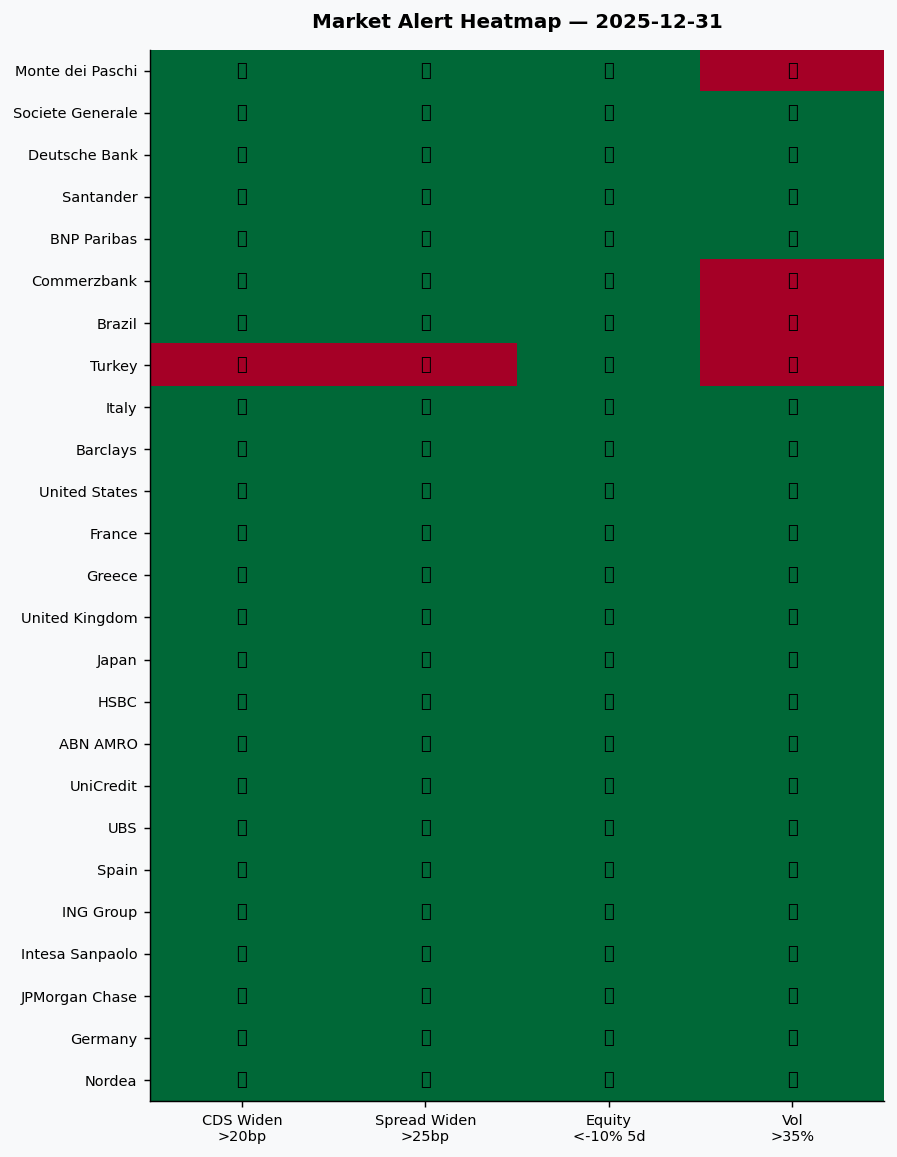

In [37]:
alert_cols = ['cds_alert','spread_alert','equity_alert','vol_alert']
alert_labels = ['CDS Widen\n>20bp','Spread Widen\n>25bp','Equity\n<-10% 5d','Vol\n>35%']

alert_df = last_market.set_index('entity_name')[alert_cols]
alert_df.columns = alert_labels
# reorder by score
alert_df = alert_df.loc[portfolio['name'].tolist()]

fig, ax = plt.subplots(figsize=(7, 9))
im = ax.imshow(alert_df.values, cmap='RdYlGn_r', vmin=0, vmax=1,
               aspect='auto', interpolation='nearest')
ax.set_xticks(range(len(alert_labels))); ax.set_xticklabels(alert_labels, fontsize=8)
ax.set_yticks(range(len(alert_df))); ax.set_yticklabels(alert_df.index, fontsize=8)
for i in range(len(alert_df)):
    for j in range(len(alert_labels)):
        ax.text(j, i, '🔴' if alert_df.iloc[i,j] else '✅',
                ha='center', va='center', fontsize=10)
ax.set_title(f'Market Alert Heatmap — {last_date.date()}',
             fontsize=11, fontweight='bold', pad=12)
plt.tight_layout(); plt.show()


## 12 · Watchlist Deep-Dive

Full analyst view for all watchlisted entities. Update `ANALYST_NOTES` each cycle.


In [38]:
wl_df = portfolio[portfolio['watchlist']].sort_values(['action','score'], ascending=[False,True])

ANALYST_NOTES = {
    'Monte dei Paschi': 'ESCALATE — CCC. NPL 12.4%, ROE –2.5%, CTI 88.4%. CDS 306 bp, vol 46.1%. Review exposure limits and collateral terms.',
    'Turkey': 'REVIEW — B. Inflation 48%, CDS 473 bp (widest). Reassess if inflation falls below 30%.',
    'Greece': 'REVIEW — B. Debt/GDP 185%, spread alert active. No near-term upside drivers.',
    'Italy': 'REVIEW — B. Debt/GDP 144%, equity –5.3% (5d). European political tail risk elevated.',
    'Societe Generale': 'REVIEW — B vs ext A–. Liquidity drag + high cost structure. CDS 129 bp confirms internal view.',
    'Brazil': 'REVIEW — BB. Fiscal deficit –6.8% of GDP. CDS 281 bp; wide EM spread.',
    'Germany': 'MONITOR — BB internal (model-driven; AA external). Strong fundamentals, clean alerts.',
}

print(f'Watchlist: {len(wl_df)} entities ({len(wl_df)/len(portfolio):.0%} of portfolio)\n')
print(f'{"Entity":<22} {"Type":<10} {"Score":>6} {"Rating":>8} {"CDS":>8} {"Alerts":>7} {"Action":<10}')
print('─'*78)
for _, r in wl_df.iterrows():
    print(f'{r["name"]:<22} {r["type"]:<10} {r["score"]:>6.2f} {r["int_rating"]:>8} '
          f'{r["cds_5y_bps"]:>8.1f} {int(r["alert_count"]):>7} {r["action"]:<10}')

print('\n── Analyst Notes ──────────────────────────────────────────────────────────')
for name, note in ANALYST_NOTES.items():
    if name in wl_df['name'].values:
        row = portfolio[portfolio['name']==name].iloc[0]
        print(f'\n[{row["action"].upper():8}] {name}  |  Score: {row["score"]:.2f}  |  {row["int_rating"]}')
        print(f'  {note}')


Watchlist: 17 entities (68% of portfolio)

Entity                 Type        Score   Rating      CDS  Alerts Action    
──────────────────────────────────────────────────────────────────────────────
Commerzbank            Bank        44.08        B    111.6       1 Review    
Brazil                 Sovereign   45.57        B    281.3       1 Review    
Turkey                 Sovereign   46.60        B    472.9       3 Review    
BNP Paribas            Bank        41.79        B     74.2       0 Monitor   
Italy                  Sovereign   47.42        B    147.7       0 Monitor   
Barclays               Bank        50.74        B     78.2       0 Monitor   
United States          Sovereign   51.06        B     29.7       0 Monitor   
France                 Sovereign   52.28        B     39.9       0 Monitor   
Greece                 Sovereign   52.57        B    271.5       0 Monitor   
United Kingdom         Sovereign   54.03        B     37.4       0 Monitor   
Japan               

## 13 · Methodology Reference

### Bank Scoring — 7-Factor Model (0–100)
| Factor | Weight | Raw metric |
|--------|--------|------------|
| CET1 ratio | 25% | `cet1_ratio` in `banks_sample.csv` |
| NPL ratio | 20% | `npl_ratio` |
| ROE | 15% | `roe` |
| Leverage ratio | 10% | `leverage_ratio` |
| Loan-to-deposit | 10% | `loan_to_deposit` |
| Cost-to-income | 10% | `cost_to_income` |
| Liquidity ratio | 10% | `liquidity_ratio` |

### Sovereign Scoring — 7-Factor Model (0–100)
| Factor | Weight | Raw metric |
|--------|--------|------------|
| Debt / GDP | 25% | `debt_gdp` in `sovereigns_sample.csv` |
| Fiscal balance (% GDP) | 20% | `fiscal_balance` |
| Inflation | 15% | `inflation` |
| FX reserves (months) | 15% | `fx_reserves_months` |
| GDP growth | 10% | `gdp_growth` |
| Political risk (1–10) | 10% | `political_risk` |
| Current account | 5% | `current_account` |

### Normalisation Formula
```python
# Standard (higher = better)
comp = (value - peer_min) / (peer_max - peer_min) * 100
# Inverse (lower = better: NPL, CTI, LDR, Debt/GDP, Inflation, Political Risk)
comp = (peer_max - value) / (peer_max - peer_min) * 100
```

---
*Prepared by Thanh Pham, MSc Finance & Data Analysis — ESSCA.*  
*Internal ratings are for risk-management purposes only.*
